In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


In [3]:
path = 'LogiReg_data.txt'
pdData = pd.read_csv(path, header=None, names=['Exam 1', 'Exam 2', 'Admitted'])
pdData.head()

,Exam 1,Exam 2,Admitted
0,56.217808,32.200043,0
1,96.550001,74.548729,1
2,81.239576,52.004919,1
3,71.906094,65.599948,0
4,40.921305,93.529653,1


In [4]:
pdData.describe()
pdData.shape

(100, 3)

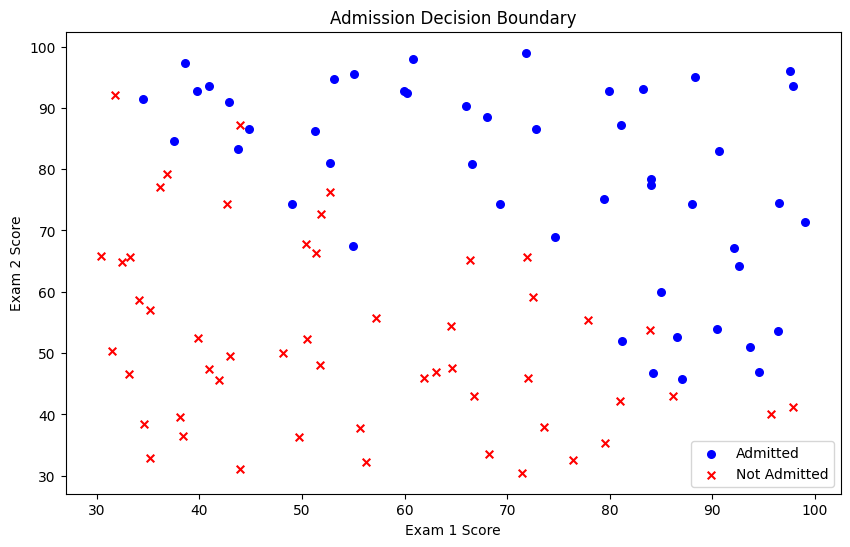

In [6]:
positive = pdData[pdData['Admitted'] == 1]
negative = pdData[pdData['Admitted'] == 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(positive['Exam 1'], positive['Exam 2'], s=30, c='b', marker='o', label='Admitted')
ax.scatter(negative['Exam 1'], negative['Exam 2'], s=30, c='r', marker='x', label='Not Admitted')
ax.legend()
ax.set_xlabel('Exam 1 Score')
ax.set_ylabel('Exam 2 Score')
ax.set_title('Admission Decision Boundary')
plt.show()

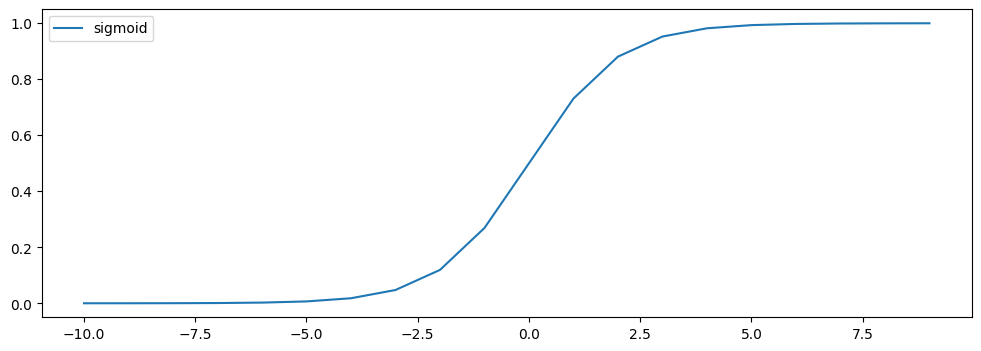

In [8]:
# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

nums = np.arange(-10, 10, step=1)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nums, sigmoid(nums), label='sigmoid')
ax.legend()
plt.show()

In [10]:
def model(X, theta):
    return sigmoid(np.dot(X, theta.T))

pdData.insert(0, 'Ones', 1)
orig_data = pdData.values
cols = orig_data.shape[1]
X = orig_data[:, 0:cols-1]
y = orig_data[:, cols-1:cols]
theta = np.zeros([1, 3])

model(X, theta)

array([[0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.5],
      

In [11]:
def cost(X, y, theta):
    left = np.multiply(-y, np.log(model(X, theta)))
    right = np.multiply((1 - y), np.log(1 - model(X, theta)))
    return np.sum(left - right) / len(X)

cost(X, y, theta)

np.float64(0.6931471805599453)

In [ ]:
def gradient(X, y, theta):
    grad = np.zeros(theta.shape)
    error = (model(X, theta) - y).ravel()
    for j in range(theta.shape[1]):
        term = np.multiply(error, X[:, j])
        grad[0, j] = np.sum(term) / len(X)
    return grad

print(gradient(X, y, theta))
print(theta)
print(X[:5])

[[ 0.02       -2.97153004 -5.34747376]]
[[0. 0. 0.]]
[[ 1.       56.217808 32.200043]
 [ 1.       96.550001 74.548729]
 [ 1.       81.239576 52.004919]
 [ 1.       71.906094 65.599948]
 [ 1.       40.921305 93.529653]]


In [ ]:
def descent(X, y, theta, alpha, iters):
    costs = [cost(X, y, theta)]
    for i in range(iters):
        grad = gradient(X, y, theta)
        theta = theta - alpha * grad
        costs.append(cost(X, y, theta))
    return theta, costs

X_scaled = X.copy().astype(float)
X_scaled[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()
X_scaled[:, 2] = (X[:, 2] - X[:, 2].mean()) / X[:, 2].std()

alpha = 0.1
iters = 5000
theta_final, costs = descent(X_scaled, y, theta, alpha, iters)
print(theta_final)
print(costs[0], costs[-1])

[[-0.60041943  3.86688548  5.10188502]]
0.6931471805599453 0.20813941161722585


In [30]:
def predict(X, theta):
    return [1 if x>=0.5 else 0 for x in model(X, theta)]

predictions = predict(X_scaled, theta_final)
correct = [1 if (a == b) else 0 for (a, b) in zip(predictions, y.ravel())]
accuracy = sum(correct) / len(correct) * 100
print("Accuracy: {:.2f}%".format(accuracy))

Accuracy: 87.00%


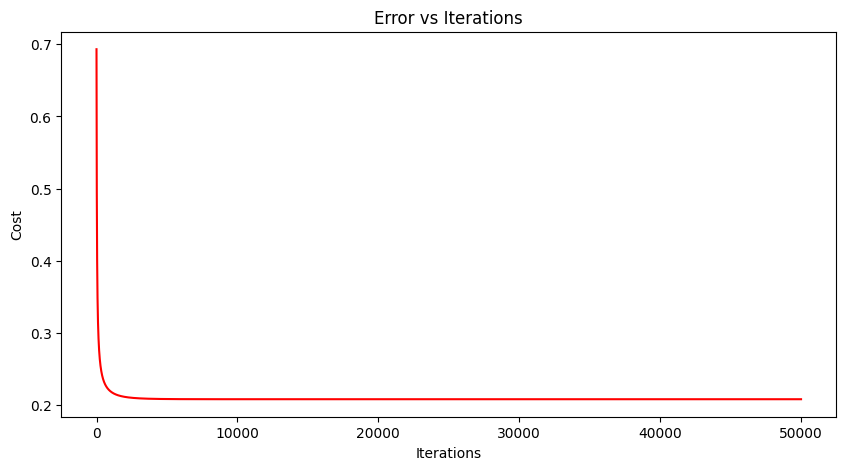

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(len(costs)), costs, 'r')
ax.set_xlabel('Iterations')
ax.set_ylabel('Cost')
ax.set_title('Error vs Iterations')
plt.show()



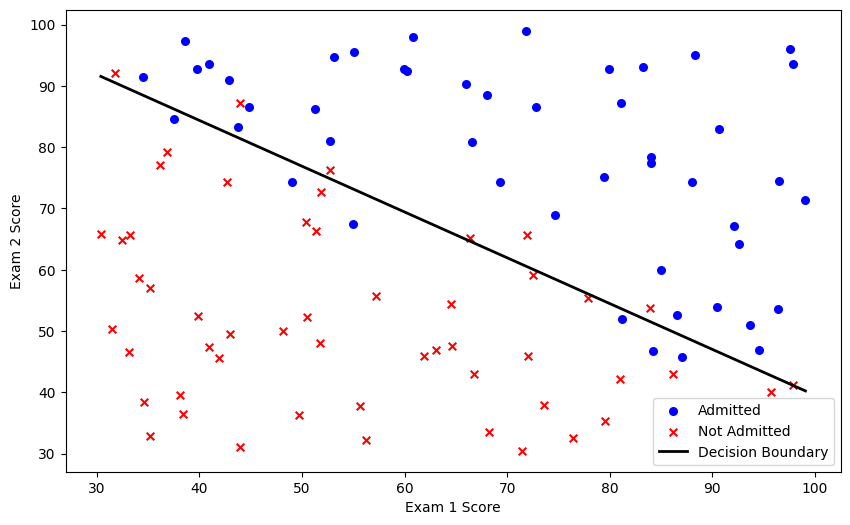

In [34]:
x1_scaled_range = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
x2_scaled_boundary = (-theta_final[0, 0] - theta_final[0, 1] * x1_scaled_range) / theta_final[0, 2]

x1_range = x1_scaled_range * X[:, 1].std() + X[:, 1].mean()
x2_boundary = x2_scaled_boundary * X[:, 2].std() + X[:, 2].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(positive['Exam 1'], positive['Exam 2'], s=30, c='blue', marker='o', label='Admitted')
ax.scatter(negative['Exam 1'], negative['Exam 2'], s=30, c='red', marker='x', label='Not Admitted')
ax.plot(x1_range, x2_boundary, color='black', linewidth=2, label='Decision Boundary')
ax.set_xlabel('Exam 1 Score')
ax.set_ylabel('Exam 2 Score')
ax.legend()
plt.show()